# Bias Analysis
This notebook evaluates potential bias in NovaCred’s historical loan approval decisions. 

## 1. Load Cleaned Dataset
We use the cleaned dataset produced in the data quality notebook.  
This ensures that inconsistent values and invalid records have already been handled before fairness analysis begins.

In [20]:
df.dtypes

_id                        object
spending_behavior          object
full_name                  object
email                      object
ssn                        object
ip_address                 object
gender                     object
date_of_birth              object
zip_code                    int64
annual_income             float64
credit_history_months     float64
debt_to_income            float64
savings_balance           float64
loan_approved                bool
rejection_reason           object
interest_rate             float64
approved_amount           float64
total_spending              int64
age                         int64
age_group                category
gender_binary               int64
dtype: object

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned dataset and Create working copy for analysis
df_original = pd.read_csv("cleaned_credit_applications.csv")
df = df_original.copy()

print(f"Dataset loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded successfully: 502 rows, 22 columns


,_id,spending_behavior,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,...,savings_balance,loan_approved,rejection_reason,interest_rate,approved_amount,total_spending,format_type,date_of_birth_parsed,date_of_birth_standardized,age
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,...,31212.0,False,algorithm_risk_score,0.0,0.0,1517,YYYY-MM-DD,2001-09-03,2001-09-03,24.0
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,...,17915.0,False,algorithm_risk_score,0.0,0.0,947,YYYY-MM-DD,NaN,1900-01-01,33.0
2,app_215,"[{'category': 'Rent', 'amount': 109}]",Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,...,37909.0,True,NaN,3.7,59000.0,109,YYYY-MM-DD,NaN,1900-01-01,36.0
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077.0,103000.0,...,0.0,True,NaN,4.3,34000.0,575,YYYY-MM-DD,NaN,1900-01-01,42.0
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080.0,57000.0,...,31763.0,False,algorithm_risk_score,0.0,0.0,463,YYYY-MM-DD,NaN,1900-01-01,26.0


## 2. Analysis Setup

We define the key columns used throughout the notebook and create filtered subsets where needed.

In [2]:
df.columns

Index(['_id', 'spending_behavior', 'full_name', 'email', 'ssn', 'ip_address',
       'gender', 'date_of_birth', 'zip_code', 'annual_income',
       'credit_history_months', 'debt_to_income', 'savings_balance',
       'loan_approved', 'rejection_reason', 'interest_rate', 'approved_amount',
       'total_spending', 'format_type', 'date_of_birth_parsed',
       'date_of_birth_standardized', 'age'],
      dtype='object')

In [3]:
df['gender'].unique()

array(['Male', 'Female', 'Unknown'], dtype=object)

In [4]:
# Define relevant columns
gender_col = 'gender'
decision_col = 'loan_approved'

# Keep only Male/Female for fairness metrics
df_gender = df[df[gender_col].isin(['Male', 'Female'])].copy()

# Calculate approval rate by gender
approval_by_gender = (
    df_gender
    .groupby(gender_col)[decision_col]
    .mean()
    .rename("approval_rate")
)

approval_by_gender

gender
Female    0.505976
Male      0.657258
Name: approval_rate, dtype: float64

## 3. Gender Bias Analysis

We analyze whether loan approval rates differ between male and female applicants.
Missing gender values are excluded to ensure fair comparison.

In [5]:
df['gender'].value_counts(dropna=False)

gender
Female     251
Male       248
Unknown      3
Name: count, dtype: int64

In [6]:
gender_col = 'gender'
decision_col = 'loan_approved'

df_gender = df[df[gender_col].isin(['Male','Female'])].copy()

df_gender.shape

(499, 22)

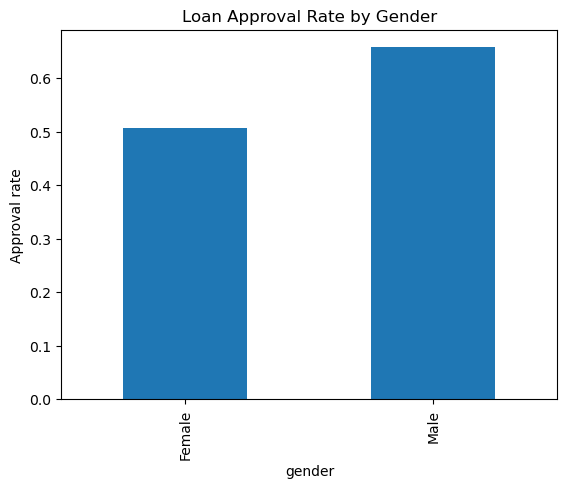

In [7]:
approval_by_gender.plot(kind="bar")
plt.ylabel("Approval rate")
plt.title("Loan Approval Rate by Gender")
plt.show()

The approval rates differ between male and female applicants.  
This difference may indicate potential gender bias in the loan approval process.

### Interpretation

The approval rates differ between male and female applicants.  
Male applicants have an approval rate of approximately 66%, while female applicants have an approval rate of about 51%.

This gap indicates a potential disparity in loan approval outcomes across genders.  
However, the difference does not automatically imply discrimination, as other factors such as income, credit history, or age may influence approval decisions.

To better assess potential bias, additional analyses such as statistical testing, proxy variable analysis, and interaction effects are performed in the following sections.

## 4. Disparate Impact (DI)

Disparate Impact measures whether approval rates differ significantly between groups.

DI = Female approval rate / Male approval rate

A DI below **0.80** may indicate potential discrimination according to the 80% rule.

In [8]:
female_rate = approval_by_gender['Female']
male_rate = approval_by_gender['Male']

DI = female_rate / male_rate

print("Disparate Impact:", DI)

Disparate Impact: 0.7698286608168553


### Interpretation

The Disparate Impact (DI) ratio is approximately **0.77**, which is below the commonly used **0.80 threshold** (the "80% rule").  

This suggests that female applicants receive loan approvals at a lower rate relative to male applicants. According to fairness guidelines, a DI value below 0.80 may indicate potential adverse impact against the disadvantaged group.

However, this metric alone does not prove discrimination, as other factors such as income, credit history, or debt-to-income ratio may also influence approval decisions.

## Demographic parity difference

In [9]:
di_ratio = female_rate / male_rate
demographic_parity_diff = female_rate - male_rate

print(f"Disparate Impact ratio: {di_ratio:.3f}")
print(f"Demographic Parity diff: {demographic_parity_diff:.3f}")

/var/folders/mt/lqgwlp595qx61nxnr067btpm0000gn/T/ipykernel_52333/2461128598.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["loan_approved"].mean()
Disparate Impact ratio: 0.770
Demographic Parity diff: -0.151


### Interpretation

The demographic parity difference is approximately **-0.151**, meaning that female applicants have an approval rate about **15 percentage points lower** than male applicants.

A negative value indicates that the protected group (female applicants) receives fewer positive outcomes compared to the reference group (male applicants).  

This disparity highlights a potential imbalance in approval outcomes across genders, which warrants further investigation.

## Chi-square test: Gender vs Loan Approval

In [10]:
from scipy.stats import chi2_contingency

# Contingency table
cont_gender = pd.crosstab(df_gender['gender'], df_gender['loan_approved'])

# Chi-square test
chi2_g, p_g, dof_g, _ = chi2_contingency(cont_gender)

print("Chi-square test: Gender vs Loan Approval")
print(f"Chi2 = {chi2_g:.4f}, p-value = {p_g:.4f}, dof = {dof_g}")

if p_g < 0.05:
    print("Result: Statistically significant difference in approval rates by gender.")
else:
    print("Result: No statistically significant difference detected.")

/var/folders/mt/lqgwlp595qx61nxnr067btpm0000gn/T/ipykernel_52333/2173826309.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["loan_approved"].mean().plot(kind="bar")
Chi-square test: Gender vs Loan Approval
Chi2 = 11.1156, p-value = 0.0009, dof = 1
Result: Statistically significant difference in approval rates by gender.


### Interpretation

The chi-square test shows a **statistically significant relationship** between gender and loan approval outcomes (p-value < 0.05).

This indicates that the observed difference in approval rates between male and female applicants is unlikely to be due to random chance. Therefore, gender appears to be associated with loan approval decisions in this dataset.

However, this test does not identify the cause of the difference. Additional analysis is needed to determine whether the disparity is driven by legitimate financial factors or potential bias in the approval process.

## 5. Age Bias Analysis

We examine whether loan approval rates differ across age groups.

In [11]:
# make age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[18,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-65']
)
#approval by age group

approval_by_age = (
    df.groupby('age_group')['loan_approved']
    .mean()
)

approval_by_age

C:\Users\inesm\AppData\Local\Temp\ipykernel_27040\4266385202.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['loan_approved']


age_group
18-25    0.571429
26-35    0.403846
36-45    0.647059
46-55    0.666667
56-65    0.657895
Name: loan_approved, dtype: float64

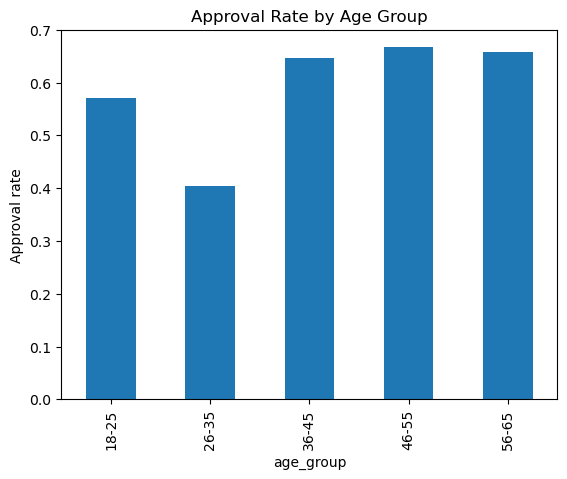

In [12]:
approval_by_age.plot(kind='bar')
plt.ylabel("Approval rate")
plt.title("Approval Rate by Age Group")
plt.show()

### Interpretation

Loan approval rates vary across age groups. Applicants aged **26–35 have the lowest approval rate (about 40%)**, while older applicants, particularly those aged **46–65**, have higher approval rates (around 65–67%).

This pattern suggests that younger applicants may face lower approval probabilities compared to older applicants. The differences may be related to factors such as credit history length, income stability, or financial experience, which often increase with age.

However, the observed differences indicate that age is associated with loan approval outcomes and should be further examined to ensure that decisions are not unintentionally disadvantaging certain age groups.

## 6. Interaction Effects: Age × Gender

We analyze whether the combination of age and gender produces compounded disadvantages.

In [13]:
df_gender = df[df['gender'].isin(['Male', 'Female'])].copy()

In [14]:
age_gender_approval = (
    df_gender
    .groupby(['age_group','gender'])['loan_approved']
    .mean()
    .unstack()
)

age_gender_approval

C:\Users\inesm\AppData\Local\Temp\ipykernel_27040\2245595101.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['age_group','gender'])['loan_approved']


gender,Female,Male
age_group,,
18-25,0.555556,0.600000
26-35,0.333333,0.489362
36-45,0.615385,0.671642
46-55,0.620690,0.703704
56-65,0.550000,0.777778


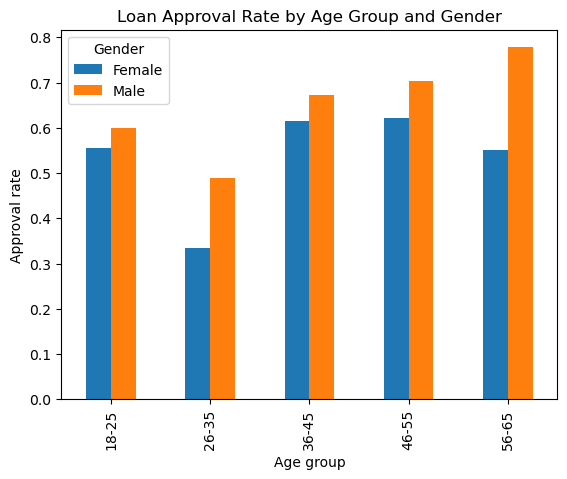

In [15]:
age_gender_approval.plot(kind='bar')

plt.ylabel("Approval rate")
plt.title("Loan Approval Rate by Age Group and Gender")
plt.xlabel("Age group")

plt.legend(title="Gender")
plt.show()

### Interpretation

The interaction analysis examines whether the combination of age and gender produces compounded disparities in loan approval outcomes.

Across all age groups, male applicants consistently show higher approval rates than female applicants. The gap is particularly noticeable in the **26–35 age group**, where female applicants have the lowest approval rate (around 33%) compared to male applicants (around 49%).

Approval rates increase for both genders in older age groups, but the difference between male and female applicants remains visible. For example, in the **56–65 age group**, male applicants have an approval rate of about 78% while female applicants have an approval rate of about 55%.

These results suggest that disparities may not only be associated with gender or age individually, but also with the **interaction between the two variables**, indicating potential compounded disadvantage for certain demographic groups.

## Proxy Discrimination Analysis (ZIP Code)

Even if protected attributes such as gender are removed from a model, other variables may act as proxy variables.

ZIP codes may reflect geographic patterns that correlate with demographic characteristics.  
We therefore examine whether loan approval rates vary across ZIP codes.

In [16]:
zip_stats = (
    df.groupby('zip_code')
    .agg(
        approval_rate=('loan_approved','mean'),
        applications=('loan_approved','size')
    )
)

zip_stats.head()

,approval_rate,applications
zip_code,,
10001.0,1.0,4
10002.0,0.6,5
10003.0,0.4,5
10004.0,1.0,6
10005.0,1.0,3


In [17]:
zip_filtered = zip_stats[zip_stats['applications'] >= 5]

zip_filtered.head()

,approval_rate,applications
zip_code,,
10002.0,0.600000,5
10003.0,0.400000,5
10004.0,1.000000,6
10012.0,1.000000,5
10019.0,0.333333,6


In [18]:
zip_filtered.sort_values('approval_rate').head(10)

/var/folders/mt/lqgwlp595qx61nxnr067btpm0000gn/T/ipykernel_52333/278729096.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["age_group", "gender"])["loan_approved"].mean()


,approval_rate,applications
zip_code,,
90205.0,0.200000,5
10096.0,0.285714,7
10019.0,0.333333,6
10003.0,0.400000,5
10044.0,0.400000,5
90284.0,0.428571,7
10057.0,0.500000,6
10041.0,0.600000,5
90237.0,0.600000,5


/var/folders/mt/lqgwlp595qx61nxnr067btpm0000gn/T/ipykernel_52333/2574995703.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction = df.groupby(["age_group", "gender"])["loan_approved"].mean().unstack()


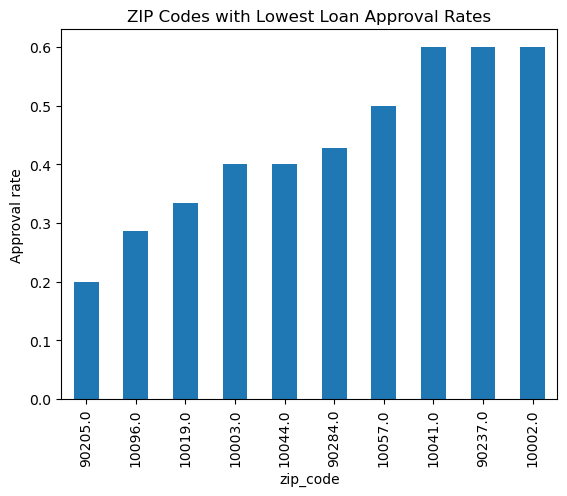

In [19]:
zip_filtered.sort_values('approval_rate').head(10)['approval_rate'].plot(kind='bar')

plt.ylabel("Approval rate")
plt.title("ZIP Codes with Lowest Loan Approval Rates")
plt.show()

### Interpretation

The approval rates vary across ZIP codes, with some areas showing substantially lower approval rates than others. For example, ZIP code 90205 has an approval rate of around 20%, while other ZIP codes have rates closer to 60%.

These differences suggest that geographic location may influence loan approval outcomes. Because ZIP codes can correlate with demographic characteristics such as income levels or population composition, they may function as proxy variables.

This means that even if protected attributes such as gender are removed from a model, geographic information could still reproduce demographic disparities in lending decisions.

### Overall Bias Analysis Summary

The bias analysis reveals several disparities in loan approval outcomes across demographic groups.

Gender analysis shows that male applicants have higher approval rates than female applicants. The Disparate Impact ratio (≈0.77) falls below the commonly used 0.80 threshold, suggesting a potential adverse impact against female applicants. The chi-square test also confirms that the difference in approval rates between genders is statistically significant.

Age-based analysis indicates that approval rates vary across age groups. Applicants aged 26–35 have the lowest approval rate, while older applicants generally receive higher approval rates.

The interaction analysis further shows that disparities persist when age and gender are considered together. Female applicants aged 26–35 appear to experience the lowest approval rates, suggesting a potential compounded disadvantage.

Finally, the proxy analysis suggests that geographic variables such as ZIP code may influence approval outcomes. Since ZIP codes can correlate with demographic characteristics, they may indirectly reproduce demographic disparities even if protected attributes are removed from the model.

### Suggested Mitigations

To reduce potential bias and improve fairness in the loan approval process, several mitigation strategies can be considered:

- **Remove or carefully review proxy variables** (such as ZIP code) that may indirectly encode demographic information.
- **Introduce fairness monitoring metrics**, such as Disparate Impact and Demographic Parity, during model evaluation.
- **Perform feature importance and fairness audits** to ensure that sensitive attributes are not disproportionately influencing predictions.
- **Apply bias mitigation techniques**, such as reweighting, resampling, or fairness-aware machine learning algorithms.
- **Implement regular bias monitoring dashboards** to track disparities in approval outcomes over time.

These measures can help ensure that automated decision systems remain fair, transparent, and aligned with ethical and regulatory guidelines.

## Assess Impact of Removing PII on Model Outputs
We first compute baseline outcome metrics before removing PII columns.

In [ ]:
# Baseline metrics (with PII present)

baseline = {}

baseline["approval_rate"] = df["loan_approved"].mean()

female_rate = df.loc[df["gender"]=="Female", "loan_approved"].mean()
male_rate   = df.loc[df["gender"]=="Male", "loan_approved"].mean()

baseline["DI_gender_F_over_M"] = female_rate / male_rate

baseline

{'approval_rate': np.float64(0.5671641791044776),
 'DI_gender_F_over_M': np.float64(0.8047052154195011)}

 ## Create dataset without PII columns
 We remove PII columns and recompute the same metrics. If results are unchanged, removing PII does not affect these outcome metrics.

In [ ]:
pii_cols = ["full_name", "email", "ssn", "ip_address", "date_of_birth"]

df_no_pii = df.drop(columns=[c for c in pii_cols if c in df.columns]).copy()

df_no_pii.columns

Index(['_id', 'spending_behavior', 'gender', 'zip_code', 'annual_income',
       'credit_history_months', 'debt_to_income', 'savings_balance',
       'loan_approved', 'rejection_reason', 'interest_rate', 'approved_amount',
       'total_spending', 'age', 'age_group', 'gender_binary'],
      dtype='object')

## Recomputing Outcome Metrics Without PII
We recompute approval rate and gender Disparate Impact using the dataset without PII columns to evaluate whether removing personal data affects outcome metrics.

In [ ]:
after = {}

after["approval_rate"] = df_no_pii["loan_approved"].mean()

female_rate2 = df_no_pii.loc[df_no_pii["gender"]=="Female", "loan_approved"].mean()
male_rate2   = df_no_pii.loc[df_no_pii["gender"]=="Male", "loan_approved"].mean()

after["DI_gender_F_over_M"] = female_rate2 / male_rate2

after

{'approval_rate': np.float64(0.5671641791044776),
 'DI_gender_F_over_M': np.float64(0.8047052154195011)}

## Compare Baseline vs After 

In [ ]:
after = {}

after["approval_rate"] = df_no_pii["loan_approved"].mean()

female_rate2 = df_no_pii.loc[df_no_pii["gender"]=="Female", "loan_approved"].mean()
male_rate2   = df_no_pii.loc[df_no_pii["gender"]=="Male", "loan_approved"].mean()

after["DI_gender_F_over_M"] = female_rate2 / male_rate2

after

{'approval_rate': np.float64(0.5671641791044776),
 'DI_gender_F_over_M': np.float64(0.8047052154195011)}

In [24]:
comparison = pd.DataFrame({"baseline": baseline, "after_no_pii": after})
comparison["difference"] = comparison["after_no_pii"] - comparison["baseline"]
comparison

,baseline,after_no_pii,difference
approval_rate,0.567164,0.567164,0.0
DI_gender_F_over_M,0.804705,0.804705,0.0


## Conclusion

After removing PII columns, both the overall approval rate and the gender Disparate Impact remain unchanged (difference = 0.0).

This indicates that personal identifiable information (PII) is not influencing these outcome metrics. The fairness-related metrics are driven by non-PII variables in the dataset.

Therefore, removing PII does not affect model output metrics in this analysis.